# Premium Prediction for Health insurance

# Step-1 : EDA

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading dataset
df = pd.read_excel("premiums.xlsx")
df

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,No Disease,Bronze,9111
49996,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,Thyroid,Gold,27076
49997,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,No Disease,Bronze,8564
49998,18,Male,Northwest,Unmarried,2,Normal,No Smoking,Salaried,10L - 25L,20,No Disease,Bronze,9490


# EDA + Data Cleaning

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Age                    50000 non-null  int64 
 1   Gender                 50000 non-null  object
 2   Region                 50000 non-null  object
 3   Marital_status         50000 non-null  object
 4   Number Of Dependants   50000 non-null  int64 
 5   BMI_Category           50000 non-null  object
 6   Smoking_Status         49989 non-null  object
 7   Employment_Status      49998 non-null  object
 8   Income_Level           49987 non-null  object
 9   Income_Lakhs           50000 non-null  int64 
 10  Medical History        50000 non-null  object
 11  Insurance_Plan         50000 non-null  object
 12  Annual_Premium_Amount  50000 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 5.0+ MB


In [4]:
df.Income_Level.unique()

array(['<10L', '10L - 25L', '> 40L', '25L - 40L', nan], dtype=object)

In [5]:
df.shape

(50000, 13)

In [6]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [7]:
df.columns = df.columns.str.replace(" " , "_")

In [8]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number_Of_Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical_History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [9]:
df.columns = df.columns.str.lower()

In [10]:
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount'],
      dtype='object')

## Handle the Null values

In [11]:
df.isnull().sum()

age                       0
gender                    0
region                    0
marital_status            0
number_of_dependants      0
bmi_category              0
smoking_status           11
employment_status         2
income_level             13
income_lakhs              0
medical_history           0
insurance_plan            0
annual_premium_amount     0
dtype: int64

In [12]:
df.dropna(inplace = True)

In [13]:
df.isnull().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

In [14]:
df.shape

(49976, 13)

## Handle duplicate values

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49976.000000,49976.000000,49976.000000,49976.000000
mean,34.591764,1.711842,23.021150,15766.810189
std,15.000378,1.498195,24.221794,8419.995271
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8607.750000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22273.500000
max,356.000000,5.000000,930.000000,43471.000000


# Numerical columns : Univariate analysis

In [17]:
## Issue-1 : number_of_dependants cannot be in negative

df[df.number_of_dependants < 0]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
402,23,Female,Southwest,Unmarried,-3,Underweight,No Smoking,Freelancer,10L - 25L,18,No Disease,Silver,9309
2245,18,Male,Southwest,Unmarried,-3,Overweight,No Smoking,Freelancer,25L - 40L,28,No Disease,Silver,8095
2323,19,Male,Northwest,Unmarried,-3,Underweight,No Smoking,Freelancer,25L - 40L,40,No Disease,Bronze,4641
2986,34,Female,Southeast,Married,-1,Underweight,Regular,Self-Employed,25L - 40L,35,High blood pressure & Heart disease,Silver,22995
3756,41,Male,Southwest,Married,-1,Obesity,Regular,Salaried,10L - 25L,21,Diabetes,Silver,22766
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48062,23,Male,Northwest,Unmarried,-1,Normal,No Smoking,Freelancer,> 40L,54,No Disease,Gold,13601
48086,36,Female,Southwest,Married,-1,Obesity,Occasional,Salaried,<10L,3,Diabetes,Bronze,14422
49256,60,Female,Southwest,Married,-1,Normal,No Smoking,Self-Employed,10L - 25L,21,Thyroid,Bronze,10141
49270,34,Male,Southeast,Married,-1,Obesity,No Smoking,Self-Employed,10L - 25L,17,Diabetes & Thyroid,Silver,21816


In [18]:
df.number_of_dependants.unique()

array([ 0,  2,  3,  4,  1,  5, -3, -1])

In [19]:
df['number_of_dependants'] = df.number_of_dependants.abs()

In [20]:
df.number_of_dependants.unique()

array([0, 2, 3, 4, 1, 5])

In [21]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49976.000000,49976.000000,49976.000000,49976.000000
mean,34.591764,1.717284,23.021150,15766.810189
std,15.000378,1.491953,24.221794,8419.995271
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8607.750000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22273.500000
max,356.000000,5.000000,930.000000,43471.000000


## Handle the Outliers

In [22]:
numeric_columns = df.select_dtypes(include = ['int64', 'float64']).columns
numeric_columns                             

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

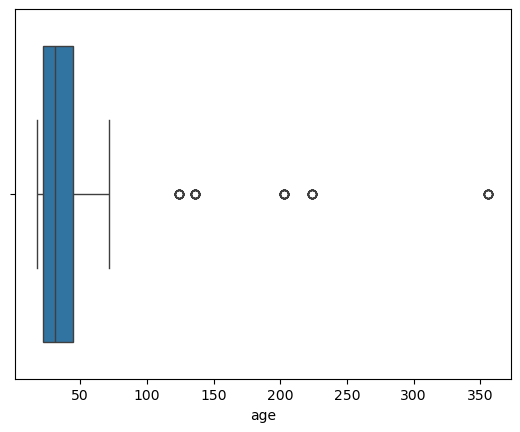

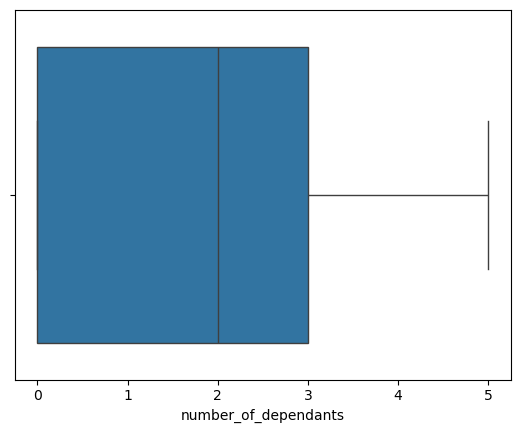

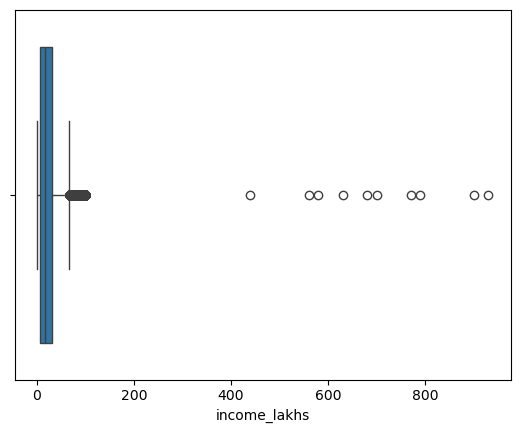

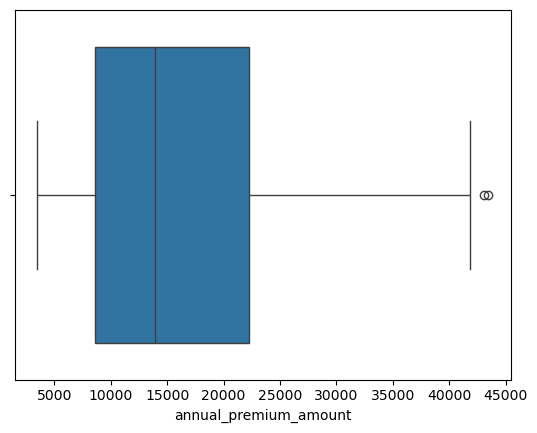

In [23]:
for col in numeric_columns:
    sns.boxplot(x = df[col])
    plt.show()

## Handling the Age Outlier

In [24]:
df[df.age > 100]['age'].count()

np.int64(58)

In [25]:
df[df.age > 100]['age'].unique()

array([224, 124, 136, 203, 356])

In [26]:
median = df.age.median()
median

31.0

In [27]:
df.loc[df.age > 100, 'age'] = median

In [28]:
df[df.age > 100]['age'].count()

np.int64(0)

In [29]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49976.000000,49976.000000,49976.000000,49976.000000
mean,34.397891,1.717284,23.021150,15766.810189
std,13.674149,1.491953,24.221794,8419.995271
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8607.750000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22273.500000
max,72.000000,5.000000,930.000000,43471.000000


In [30]:
## Outliers in income_lakhs > 1CR (100)

df[df.income_lakhs > 100]['income_lakhs'].count()

np.int64(10)

In [31]:
# Number of outliers using IQR

Q1, Q3 = df.income_lakhs.quantile([0.25, 0.75])
IQR = Q3 - Q1
LB = Q1 - 1.5 * IQR
UB = Q3 + 1.5 * IQR

LB, UB

(-29.0, 67.0)

In [32]:
df[df.income_lakhs > UB]['income_lakhs'].count()

np.int64(3560)

In [33]:
df = df[df.income_lakhs <= 100]

In [34]:
df.shape

(49966, 13)

In [35]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49966.000000,49966.000000,49966.000000,49966.000000
mean,34.397630,1.717308,22.886063,15765.961574
std,13.674151,1.491911,22.166488,8419.532784
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8607.250000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22272.000000
max,72.000000,5.000000,100.000000,43471.000000


# EDA & DC on Caegorical data

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49966 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    49966 non-null  int64 
 1   gender                 49966 non-null  object
 2   region                 49966 non-null  object
 3   marital_status         49966 non-null  object
 4   number_of_dependants   49966 non-null  int64 
 5   bmi_category           49966 non-null  object
 6   smoking_status         49966 non-null  object
 7   employment_status      49966 non-null  object
 8   income_level           49966 non-null  object
 9   income_lakhs           49966 non-null  int64 
 10  medical_history        49966 non-null  object
 11  insurance_plan         49966 non-null  object
 12  annual_premium_amount  49966 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 5.3+ MB


In [37]:
categorical_columns = df.select_dtypes(include = ['object']).columns
categorical_columns

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [38]:
# checking sub-categories of each column
for col in categorical_columns:
    print(col, " : ", df[col].unique())

gender  :  ['Male' 'Female']
region  :  ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status  :  ['Unmarried' 'Married']
bmi_category  :  ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status  :  ['No Smoking' 'Regular' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
employment_status  :  ['Salaried' 'Self-Employed' 'Freelancer']
income_level  :  ['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history  :  ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan  :  ['Bronze' 'Silver' 'Gold']


In [39]:
df['smoking_status'] = df.smoking_status.replace({'Smoking=0' : 'No Smoking', 'Does Not Smoke' : 'No Smoking', 'Not Smoking' :  'No Smoking'})

C:\Users\Prikshit_Ishi\AppData\Local\Temp\ipykernel_21512\2744095914.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['smoking_status'] = df.smoking_status.replace({'Smoking=0' : 'No Smoking', 'Does Not Smoke' : 'No Smoking', 'Not Smoking' :  'No Smoking'})


In [40]:
df.smoking_status.unique()

array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

In [41]:
df.shape

(49966, 13)

# Step-2 : Feature Engineering

In [42]:
# checking sub-categories of each column
for col in categorical_columns:
    print(col, " : ", df[col].unique())

gender  :  ['Male' 'Female']
region  :  ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status  :  ['Unmarried' 'Married']
bmi_category  :  ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status  :  ['No Smoking' 'Regular' 'Occasional']
employment_status  :  ['Salaried' 'Self-Employed' 'Freelancer']
income_level  :  ['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history  :  ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan  :  ['Bronze' 'Silver' 'Gold']


In [43]:
risk_score = {
    'Diabetes' : 6,
    'Heart disease' : 8,
    'High blood pressure' : 6,
    'Thyroid' : 5,
    'No Disease' : 0
}

In [44]:
df1 = df.copy()

In [45]:
df1[['disease1', 'disease2']] = df1['medical_history'].str.split(" & ", expand = True)

In [46]:
df1.disease1 = df1.disease1.map(risk_score)

In [47]:
df1.disease2 = df1.disease2.map(risk_score)

In [48]:
df1.disease1.isnull().sum()

np.int64(0)

In [49]:
df1.disease2.isnull().sum()

np.int64(45192)

In [50]:
df1.disease2 = df1.disease2.fillna(0)

In [51]:
df1

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,6,0.0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,6,0.0
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,6,0.0
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,0,0.0
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,6,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,No Disease,Bronze,9111,0,0.0
49996,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,Thyroid,Gold,27076,5,0.0
49997,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,No Disease,Bronze,8564,0,0.0
49998,18,Male,Northwest,Unmarried,2,Normal,No Smoking,Salaried,10L - 25L,20,No Disease,Bronze,9490,0,0.0


In [52]:
df1['total_risk_score'] = df1['disease1'] + df1['disease2']

In [53]:
df1 = df1.drop(['medical_history', 'disease1', 'disease2'], axis = 1)
df1

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,total_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Bronze,9053,6.0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Bronze,16339,6.0
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,Silver,18164,6.0
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,Gold,20303,0.0
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,Silver,13365,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,Bronze,9111,0.0
49996,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,Gold,27076,5.0
49997,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,Bronze,8564,0.0
49998,18,Male,Northwest,Unmarried,2,Normal,No Smoking,Salaried,10L - 25L,20,Bronze,9490,0.0


In [54]:
# checking sub-categories of each column
categorical_columns = df1.select_dtypes(include = ['object']).columns
categorical_columns

for col in categorical_columns:
    print(col, " : ", df1[col].unique())

gender  :  ['Male' 'Female']
region  :  ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status  :  ['Unmarried' 'Married']
bmi_category  :  ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status  :  ['No Smoking' 'Regular' 'Occasional']
employment_status  :  ['Salaried' 'Self-Employed' 'Freelancer']
income_level  :  ['<10L' '10L - 25L' '> 40L' '25L - 40L']
insurance_plan  :  ['Bronze' 'Silver' 'Gold']


### Apply Ordinal encoding to convert insurance_plan & income_level into neumerical

In [55]:
# use ordinal encoding when Order/Ranking matters

In [56]:
from sklearn.preprocessing import OrdinalEncoder

In [57]:
encoder = OrdinalEncoder(categories = [['Bronze','Silver','Gold']])
df1['insurance_plan'] = encoder.fit_transform(df1[['insurance_plan']])

In [58]:
encoder = OrdinalEncoder(categories = [['<10L','10L - 25L','25L - 40L', '> 40L']])
df1['income_level'] = encoder.fit_transform(df1[['income_level']])

In [59]:
df1

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,total_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,0.0,6,0.0,9053,6.0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,0.0,6,0.0,16339,6.0
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,1.0,20,1.0,18164,6.0
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,3.0,77,2.0,20303,0.0
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,3.0,99,1.0,13365,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,2.0,35,0.0,9111,0.0
49996,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,3.0,82,2.0,27076,5.0
49997,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,2.0,32,0.0,8564,0.0
49998,18,Male,Northwest,Unmarried,2,Normal,No Smoking,Salaried,1.0,20,0.0,9490,0.0


## Apply Label encoder on region and bmi_category

In [60]:
# Order/Ranking don't matter in Label encoding

In [61]:
from sklearn.preprocessing import LabelEncoder

In [62]:
encoder = LabelEncoder()
for col in ['region', 'bmi_category']:
    df1[col] = encoder.fit_transform(df1[col])

In [63]:
df1

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,total_risk_score
0,26,Male,1,Unmarried,0,0,No Smoking,Salaried,0.0,6,0.0,9053,6.0
1,29,Female,2,Married,2,1,Regular,Salaried,0.0,6,0.0,16339,6.0
2,49,Female,0,Married,2,0,No Smoking,Self-Employed,1.0,20,1.0,18164,6.0
3,30,Female,2,Married,3,0,No Smoking,Salaried,3.0,77,2.0,20303,0.0
4,18,Male,0,Unmarried,0,2,Regular,Self-Employed,3.0,99,1.0,13365,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,24,Female,1,Unmarried,0,3,No Smoking,Self-Employed,2.0,35,0.0,9111,0.0
49996,47,Female,2,Married,2,0,No Smoking,Salaried,3.0,82,2.0,27076,5.0
49997,21,Male,1,Unmarried,0,0,Regular,Freelancer,2.0,32,0.0,8564,0.0
49998,18,Male,1,Unmarried,2,0,No Smoking,Salaried,1.0,20,0.0,9490,0.0


### convert into numeric using one-hot encoding

In [64]:
df.smoking_status.unique()

array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

In [65]:
df1 = pd.get_dummies(df1, columns = ['gender', 'marital_status', 'smoking_status', 'employment_status'], drop_first = True, dtype = int)

In [66]:
df1

,age,region,number_of_dependants,bmi_category,income_level,income_lakhs,insurance_plan,annual_premium_amount,total_risk_score,gender_Male,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,1,0,0,0.0,6,0.0,9053,6.0,1,1,0,0,1,0
1,29,2,2,1,0.0,6,0.0,16339,6.0,0,0,0,1,1,0
2,49,0,2,0,1.0,20,1.0,18164,6.0,0,0,0,0,0,1
3,30,2,3,0,3.0,77,2.0,20303,0.0,0,0,0,0,1,0
4,18,0,0,2,3.0,99,1.0,13365,6.0,1,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,24,1,0,3,2.0,35,0.0,9111,0.0,0,1,0,0,0,1
49996,47,2,2,0,3.0,82,2.0,27076,5.0,0,0,0,0,1,0
49997,21,1,0,0,2.0,32,0.0,8564,0.0,1,1,0,1,0,0
49998,18,1,2,0,1.0,20,0.0,9490,0.0,1,1,0,0,1,0


## finding correlation 

<Axes: >

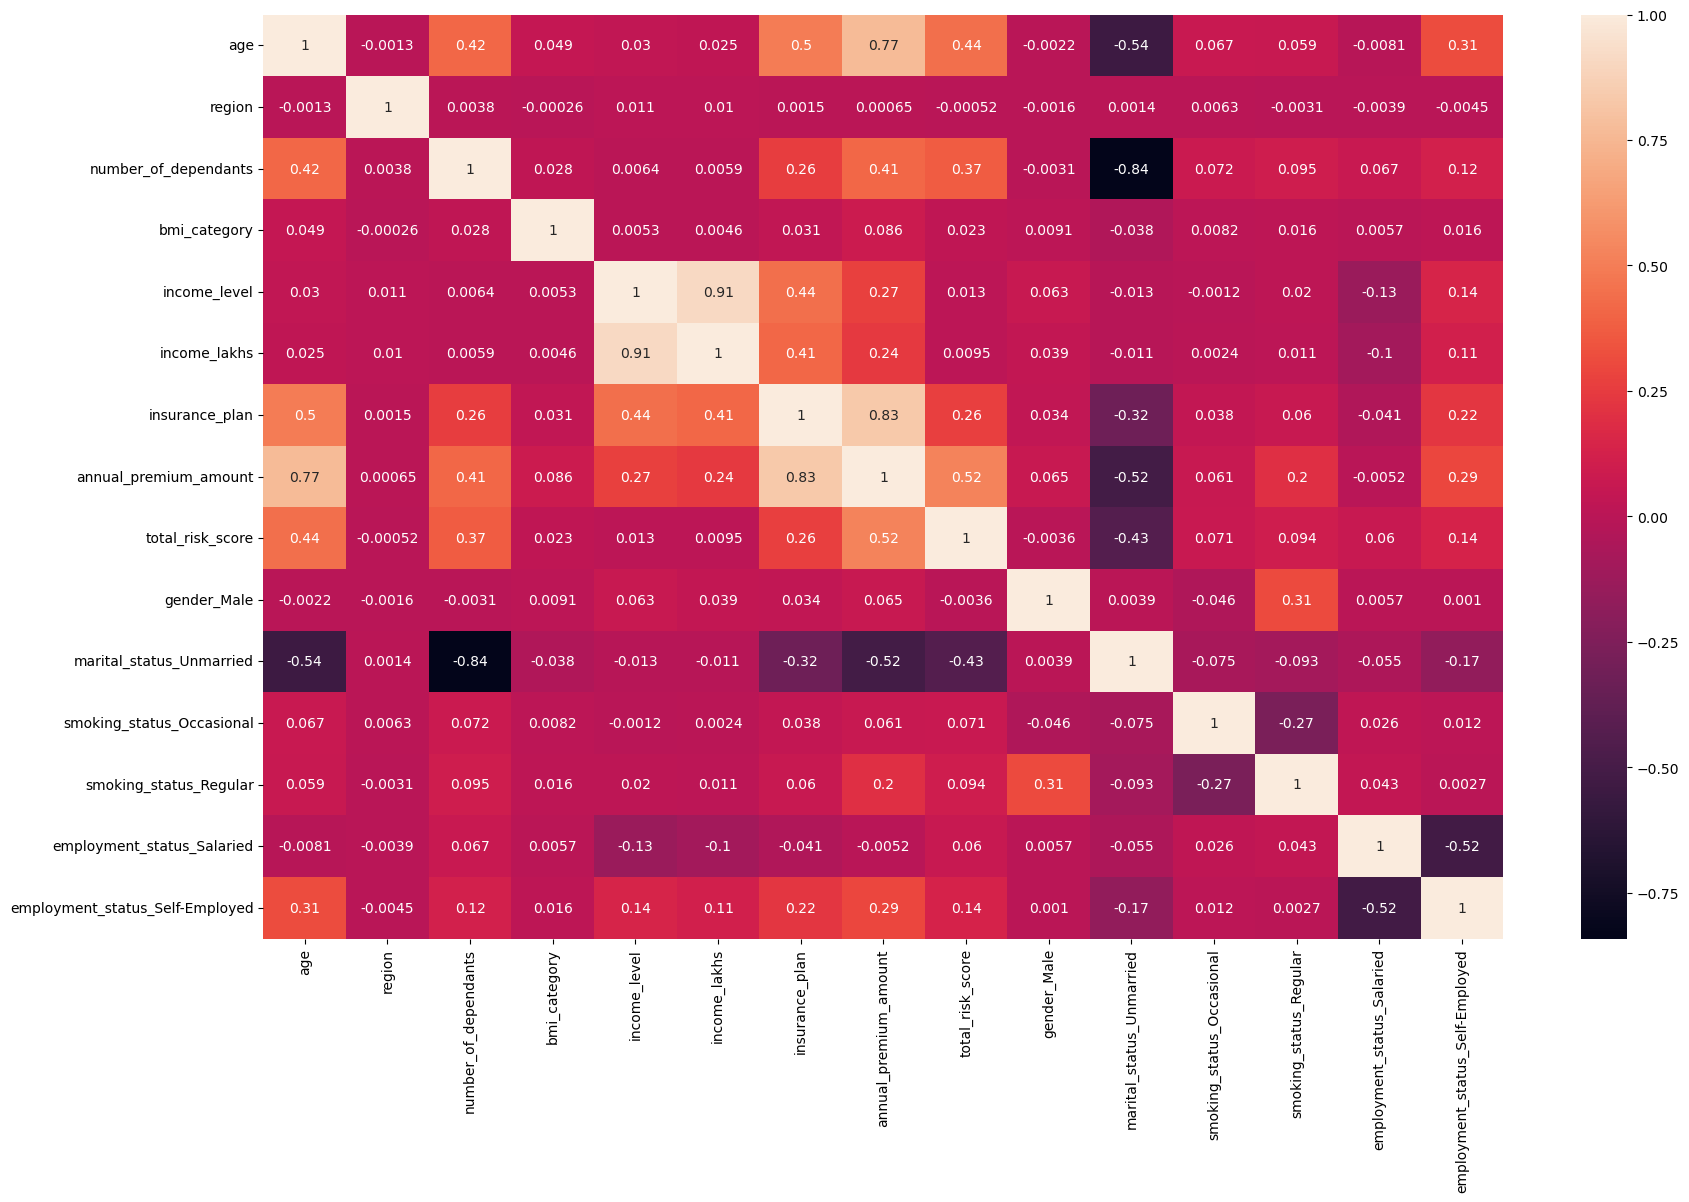

In [67]:
cm = df1.corr()

plt.figure(figsize = (20,12))
sns.heatmap(cm, annot = True)



# income_level = income_lakhs   & number_of_dependents = marital_status_unmarried

In [68]:
# income_level = income_lakhs   & number_of_dependents = marital_status_unmarried

## feature scaling

In [69]:
x = df1.drop(["income_level", "marital_status_Unmarried", "annual_premium_amount"], axis = 1)
y = df1.annual_premium_amount
x.columns

Index(['age', 'region', 'number_of_dependants', 'bmi_category', 'income_lakhs',
       'insurance_plan', 'total_risk_score', 'gender_Male',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed'],
      dtype='object')

In [70]:
from sklearn.model_selection import train_test_split

In [71]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [72]:
from sklearn.preprocessing import MinMaxScaler   # 0 to 1

scaler = MinMaxScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [73]:
x_train_scaled.shape

(39972, 12)

In [74]:
x_test_scaled.shape

(9994, 12)

# Step-3 : Apply ML models

### Linear Regression

In [75]:
from sklearn.linear_model import LinearRegression

linear_obj = LinearRegression()

linear_obj.fit(x_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [76]:
lr_score = linear_obj.score(x_test_scaled, y_test)
print(lr_score)

0.9102146048025952


### model-2 : XGBoost

In [77]:
from xgboost import XGBRegressor

In [78]:
XGB_obj = XGBRegressor()

In [79]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
                'n_estimators' : [50, 60, 70, 80, 90, 100],
                'max_depth' : [3,4,5,6,7,8,9,10]
}

random_search = RandomizedSearchCV(XGB_obj, param_grid, cv = 5)

In [80]:
random_search.fit(x_train_scaled, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [3, 4, ...], 'n_estimators': [50, 60, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold t

In [81]:
random_search.best_score_

np.float64(0.9815284132957458)

# CONGRATULATIONS - TARGET-1 ACHIEVED

# TARGET-2

In [82]:
y_pred = random_search.predict(x_test_scaled)
y_pred

array([11981.981, 11520.818, 16557.275, ..., 19070.432, 10085.21 ,
       10952.092], dtype=float32)

In [83]:
residuals = y_pred - y_test

residuals_pct = (residuals / y_test) * 100
residuals_pct

12348    -0.811412
22412     0.530701
46377    -1.509277
39797   -23.834050
23825    -1.617141
           ...    
36470     0.311270
7200      4.236368
3582      2.276261
22051    12.032992
20039    -1.456795
Name: annual_premium_amount, Length: 9994, dtype: float64

In [84]:
result_df = pd.DataFrame({
    'Actual' : y_test,
    'Predicted' : y_pred,
    'diff' : residuals,
    'diff_pct' : residuals_pct })

result_df 

,Actual,Predicted,diff,diff_pct
12348,12080,11981.981445,-98.018555,-0.811412
22412,11460,11520.818359,60.818359,0.530701
46377,16811,16557.275391,-253.724609,-1.509277
39797,9246,7042.303711,-2203.696289,-23.834050
23825,9778,9619.875977,-158.124023,-1.617141
...,...,...,...,...
36470,22011,22079.513672,68.513672,0.311270
7200,9574,9979.589844,405.589844,4.236368
3582,18646,19070.431641,424.431641,2.276261
22051,9002,10085.209961,1083.209961,12.032992


<Axes: xlabel='diff_pct', ylabel='Count'>

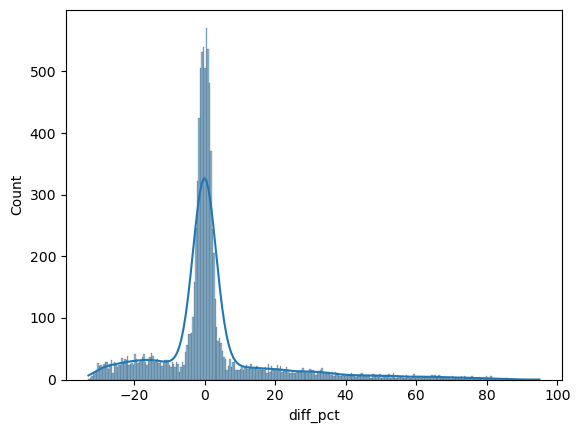

In [85]:
sns.histplot(result_df ['diff_pct'], kde = True)

In [86]:
extreme_result_df = result_df[np.abs(result_df.diff_pct) > 10]
extreme_result_df 

,Actual,Predicted,diff,diff_pct
39797,9246,7042.303711,-2203.696289,-23.834050
2576,10631,7347.642578,-3283.357422,-30.884747
49371,5218,6673.490723,1455.490723,27.893651
36676,8769,9888.981445,1119.981445,12.772054
24073,5663,6513.378418,850.378418,15.016394
...,...,...,...,...
30617,10911,9804.284180,-1106.715820,-10.143120
28612,7557,6518.631836,-1038.368164,-13.740481
48334,10466,8349.789062,-2116.210938,-20.219864
48039,10466,8233.361328,-2232.638672,-21.332301


### Create extreme_result_df with all the features

In [115]:
extreme_error_df = x_test.loc[extreme_result_df.index]
extreme_error_df

error_percentage = (extreme_error_df.shape[0] / x_test.shape[0]) * 100
print(error_percentage)

29.597758655193118


In [111]:
extreme_error_df.age.unique()

array([21, 19, 18, 22, 20, 24, 25, 23, 31])

### Finding the problem at Data level

In [87]:
df1.columns

Index(['age', 'region', 'number_of_dependants', 'bmi_category', 'income_level',
       'income_lakhs', 'insurance_plan', 'annual_premium_amount',
       'total_risk_score', 'gender_Male', 'marital_status_Unmarried',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed'],
      dtype='object')

In [88]:
# We need to find due to which feature "predicted - actual" difference is high

<Axes: xlabel='age', ylabel='Count'>

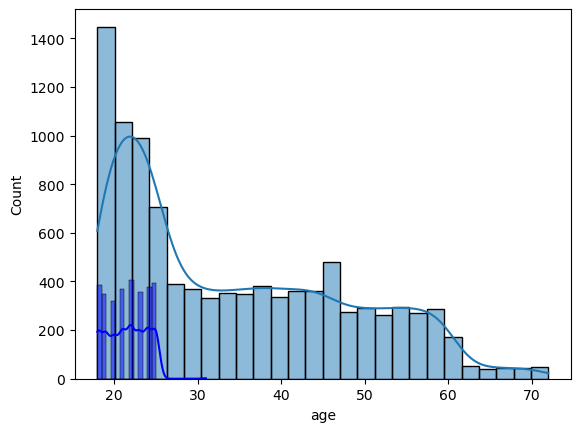

In [95]:
sns.histplot(x_test['age'], kde = True)
sns.histplot(extreme_error_df['age'], color = 'blue', kde = True)

<Axes: xlabel='region', ylabel='Count'>

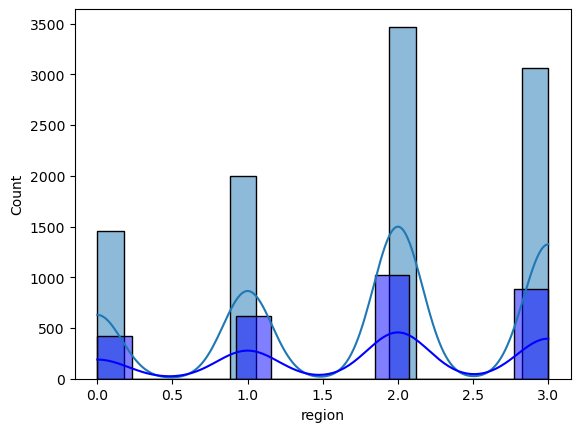

In [96]:
sns.histplot(x_test['region'], kde = True)
sns.histplot(extreme_error_df['region'], color = 'blue', kde = True)

In [97]:
x_test.shape

(9994, 12)

In [98]:
extreme_error_df.shape

(2958, 12)

In [99]:
# if the shape of error data and actual data is different for a feature
# that's means problem is occuring due to that particular feature

<Axes: xlabel='number_of_dependants', ylabel='Count'>

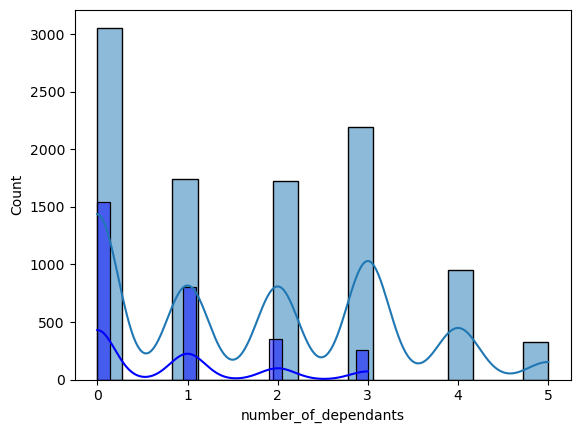

In [100]:
sns.histplot(x_test['number_of_dependants'], kde = True)
sns.histplot(extreme_error_df['number_of_dependants'], color = 'blue', kde = True)

In [106]:
type(x_test)

pandas.core.frame.DataFrame

In [113]:
x_test[x_test.age < 25]

,age,region,number_of_dependants,bmi_category,income_lakhs,insurance_plan,total_risk_score,gender_Male,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
22412,23,1,3,2,56,1.0,6.0,1,1,0,1,0
39797,21,3,0,0,26,0.0,0.0,1,0,1,0,1
2576,19,3,3,0,31,0.0,8.0,1,0,0,0,0
49371,19,3,0,3,24,0.0,0.0,1,0,0,1,0
726,23,1,0,2,22,0.0,0.0,1,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
28612,21,2,0,0,5,0.0,0.0,0,0,0,1,0
48334,18,3,3,0,9,0.0,12.0,1,0,1,0,1
36529,19,2,0,2,8,0.0,0.0,1,0,1,0,0
7200,21,2,0,0,3,1.0,0.0,1,0,0,1,0


In [114]:
# People with age less then 24 are unpredicatable

# people whose age < 24, their the "predict - actual' difference is more

# Data Segmentation